#**Data Mining and Machine Learning Project**

 Breast Cancer Classification Using Machine Learning

## Project Overview

This project aims to build a machine learning model to classify breast tumors as either malignant or benign based on diagnostic measurements. The project includes data understanding, preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and deployment.**bold text**

##1. Preparing the work environment

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

##2. Download Dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column
df['target'] = cancer.target

# Show first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


We download the data directly from the Scikit-learn Official Website, which is better than an external CSV file because it is reliable, readily available, and academically recognized.

##3. Understanding the data

In [3]:
#Knowing the number of rows and columns:
df.shape

(569, 31)

In [4]:
#Knowing the column names:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [5]:
#Understanding data types:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
#General statistics:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [7]:
#Knowing the target distribution:
df['target'].value_counts()

,count
target,
1,357
0,212


In [8]:
#Understanding the meaning of Target
print(cancer.target_names)

['malignant' 'benign']


##4. Features

In [9]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [10]:
#Knowing the number of features:
print("Number of Features:", len(cancer.feature_names))

Number of Features: 30


##5. Initial Data Assessment

In [11]:
#Checking for Missing Values:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


As long as zeros appear, it means there are no missing values.

In [12]:
#Checking for duplicate rows:
df.duplicated().sum()

np.int64(0)

In [13]:
#Data type inspection:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [14]:
#Examine the Target's distribution pattern:
df.isnull().sum()
df.duplicated().sum()
df.dtypes
df['target'].value_counts(normalize=True) * 100

,proportion
target,
1,62.741652
0,37.258348


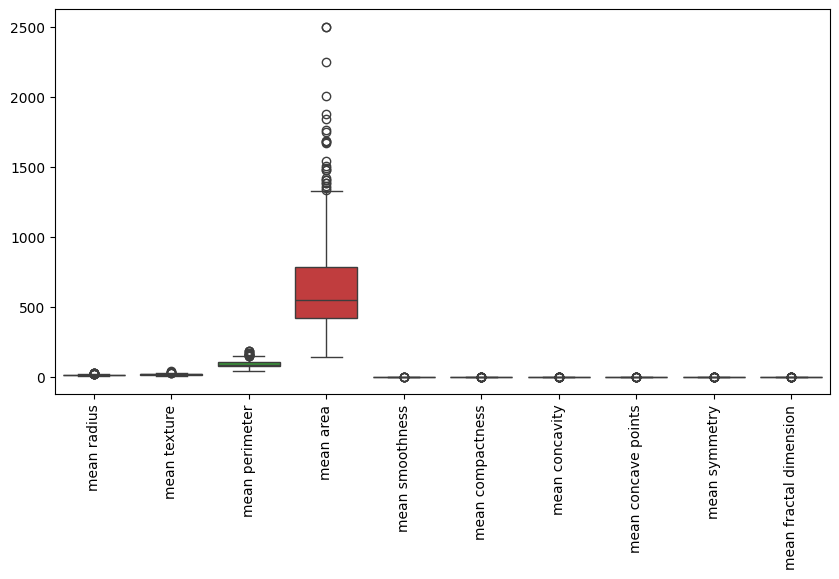

In [15]:
#Detecting outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df.iloc[:, :10])
plt.xticks(rotation=90)
plt.show()

##6. Data Cleaning

###Create a working copy

In [16]:
#We do not work directly on the original data
df_clean = df.copy()

###6.1 Addressing Missing Values

In [17]:
df_clean.isnull().sum().sum()

np.int64(0)

No missing values were found in the dataset.

###6.2 Remove duplicate rows

In [18]:
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)

(569, 31)


We calculate the number of deleted rows:

In [19]:
print("Original Shape:", df.shape)
print("After Removing Duplicates:", df_clean.shape)

Original Shape: (569, 31)
After Removing Duplicates: (569, 31)


###6.3 Data type verification

In [20]:
df_clean.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


All variables are already numerical and suitable for machine learning models.

###6.4 Data Cleaning Summary

- No missing values were detected.
- Duplicate records were checked and removed.
- Data types were verified.
- The dataset is ready for preprocessing and exploratory analysis.

##7. Exploratory Data Analysis (EDA)

###7.1 Understanding Target Distribution

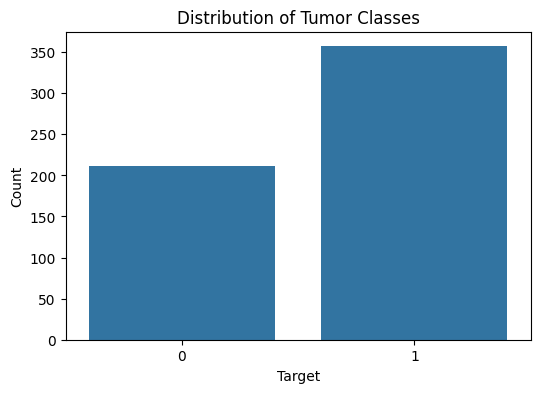

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df_clean
)

plt.title('Distribution of Tumor Classes')
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

**Observation**

The dataset contains two classes:
- Malignant tumors
- Benign tumors

The class distribution appears reasonably balanced, making the dataset suitable for classification tasks.

###7.2 First Feature Study

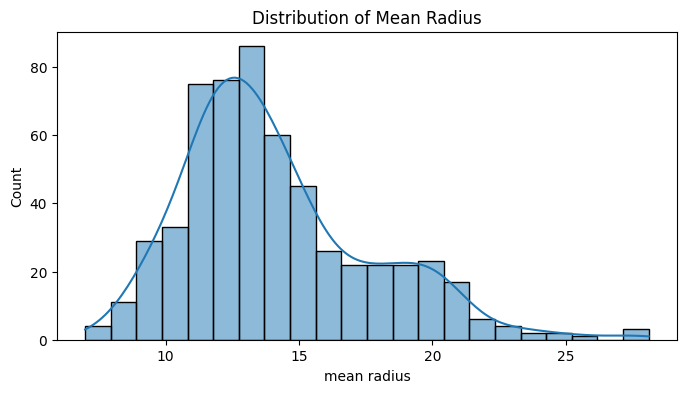

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_clean['mean radius'],
    kde=True
)

plt.title('Distribution of Mean Radius')

plt.show()

**Observation**

The mean radius values are not uniformly distributed and tend to cluster around a central range.

###7.3 Study of the second Feature

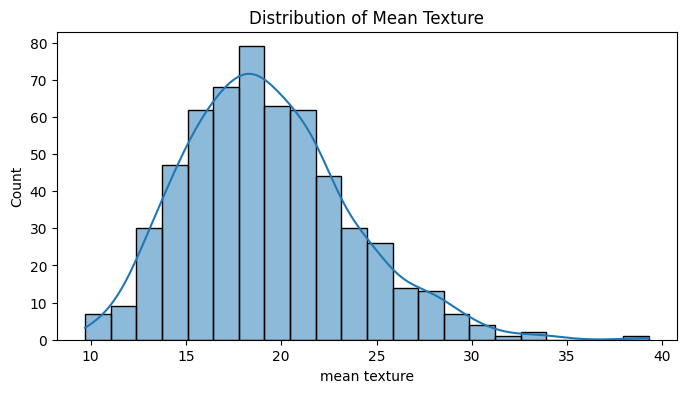

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_clean['mean texture'],
    kde=True
)

plt.title('Distribution of Mean Texture')

plt.show()

###7.4 Comparing the first feature with the target

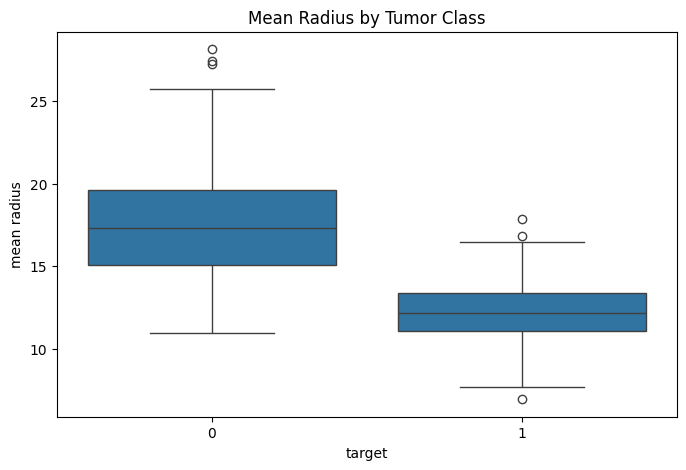

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='mean radius',
    data=df_clean
)

plt.title('Mean Radius by Tumor Class')

plt.show()

###7.5 Correlation Heatmap

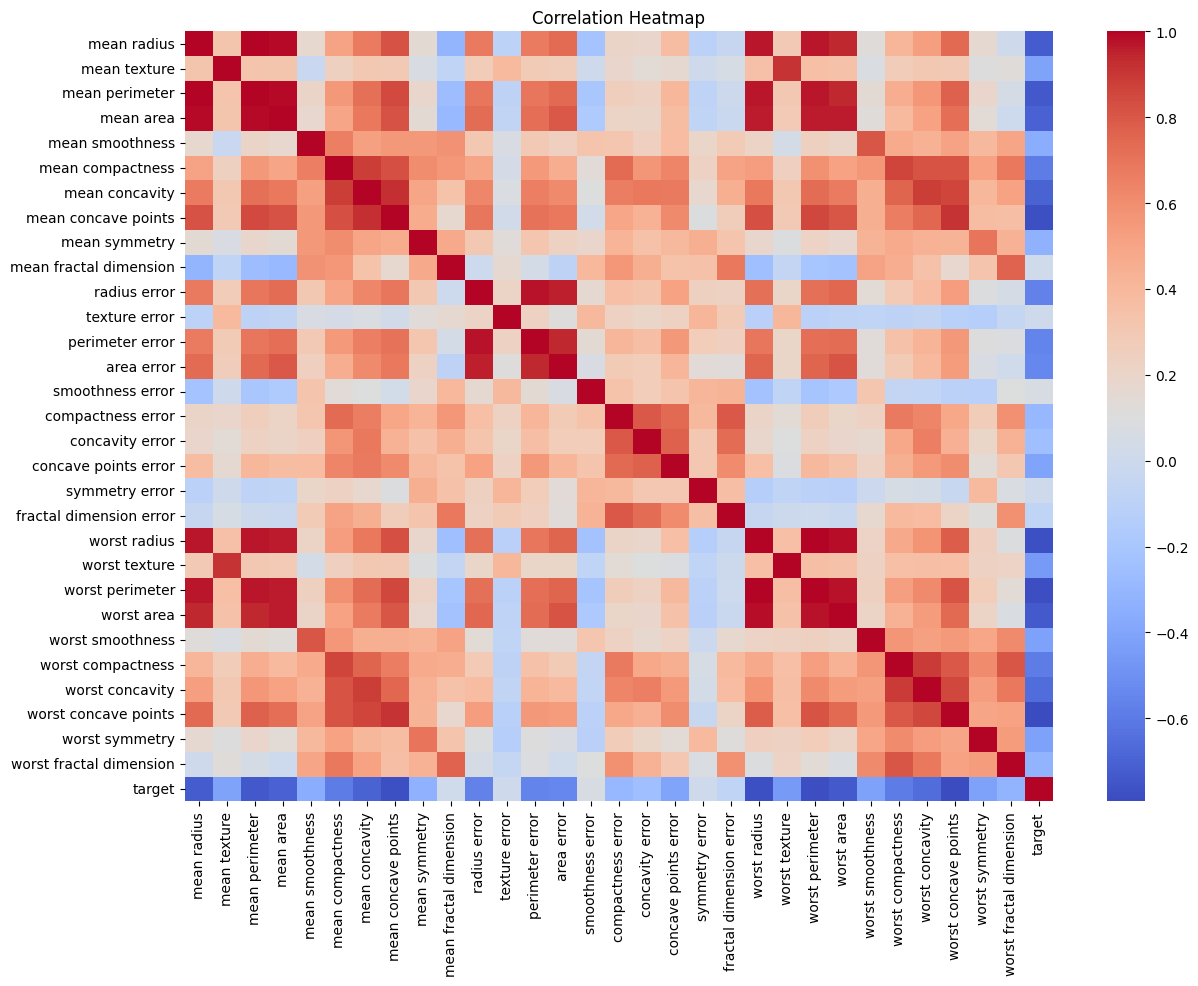

In [25]:
plt.figure(figsize=(14,10))

corr_matrix = df_clean.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Observation**

The heatmap reveals strong positive and negative correlations between several features. Highly correlated features may contain redundant information and can be useful during feature selection.

###7.6 Strongest relationships with Target

In [26]:
target_corr = df_clean.corr()['target'].sort_values(ascending=False)

target_corr

,target
target,1.000000
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499


In [27]:
target_corr.head(10)

,target
target,1.000000
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499


In [28]:
target_corr.tail(10)

,target
worst concavity,-0.659610
mean concavity,-0.696360
mean area,-0.708984
mean radius,-0.730029
worst area,-0.733825
mean perimeter,-0.742636
worst radius,-0.776454
mean concave points,-0.776614
worst perimeter,-0.782914
worst concave points,-0.793566


The goal is to identify:
- Most features associated with benign tumors
- Most features associated with malignant tumors

###7.7 Scatter Plot

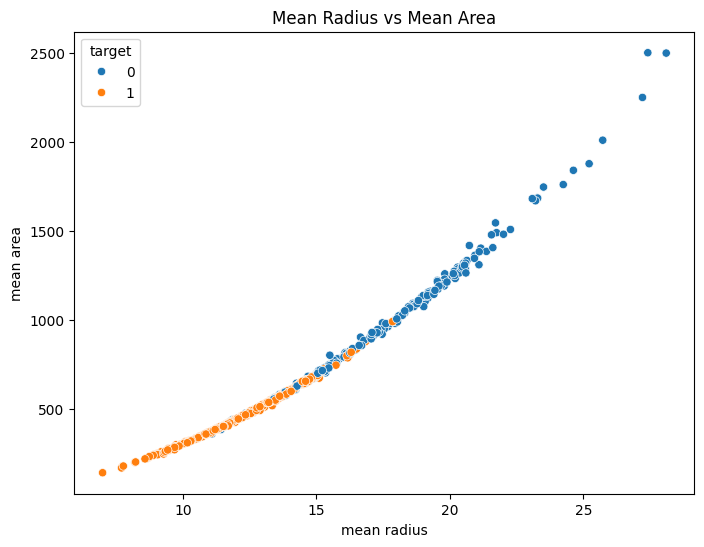

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='mean radius',
    y='mean area',
    hue='target',
    data=df_clean
)

plt.title('Mean Radius vs Mean Area')

plt.show()

**Observation**

A relationship can be observed between mean radius and mean area. The two tumor classes show noticeable separation in some regions of the plot.

###7.8 Boxplot Extra

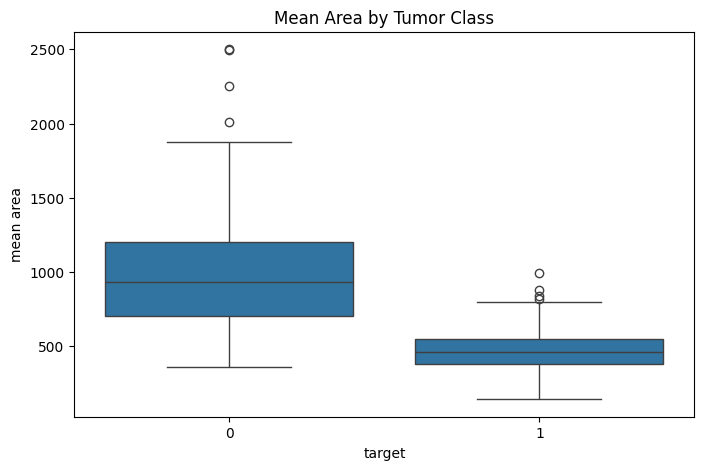

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='mean area',
    data=df_clean
)

plt.title('Mean Area by Tumor Class')

plt.show()

###7.9 Distributing another Feature

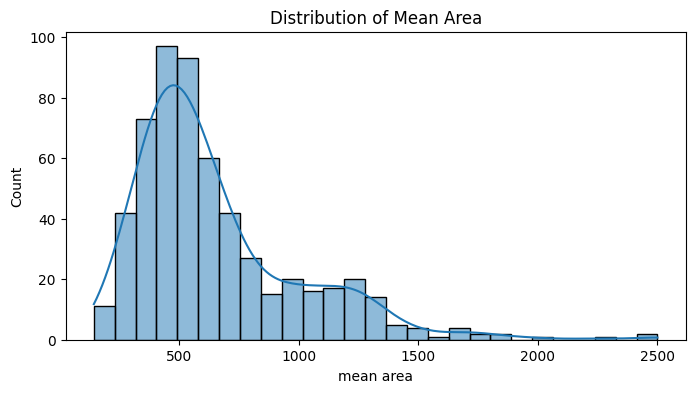

In [31]:
plt.figure(figsize=(8,4))

sns.histplot(
    df_clean['mean area'],
    kde=True
)

plt.title('Distribution of Mean Area')

plt.show()

###7.10 Pairplot

Because it's relatively large, I'll only choose the top 5 variables.

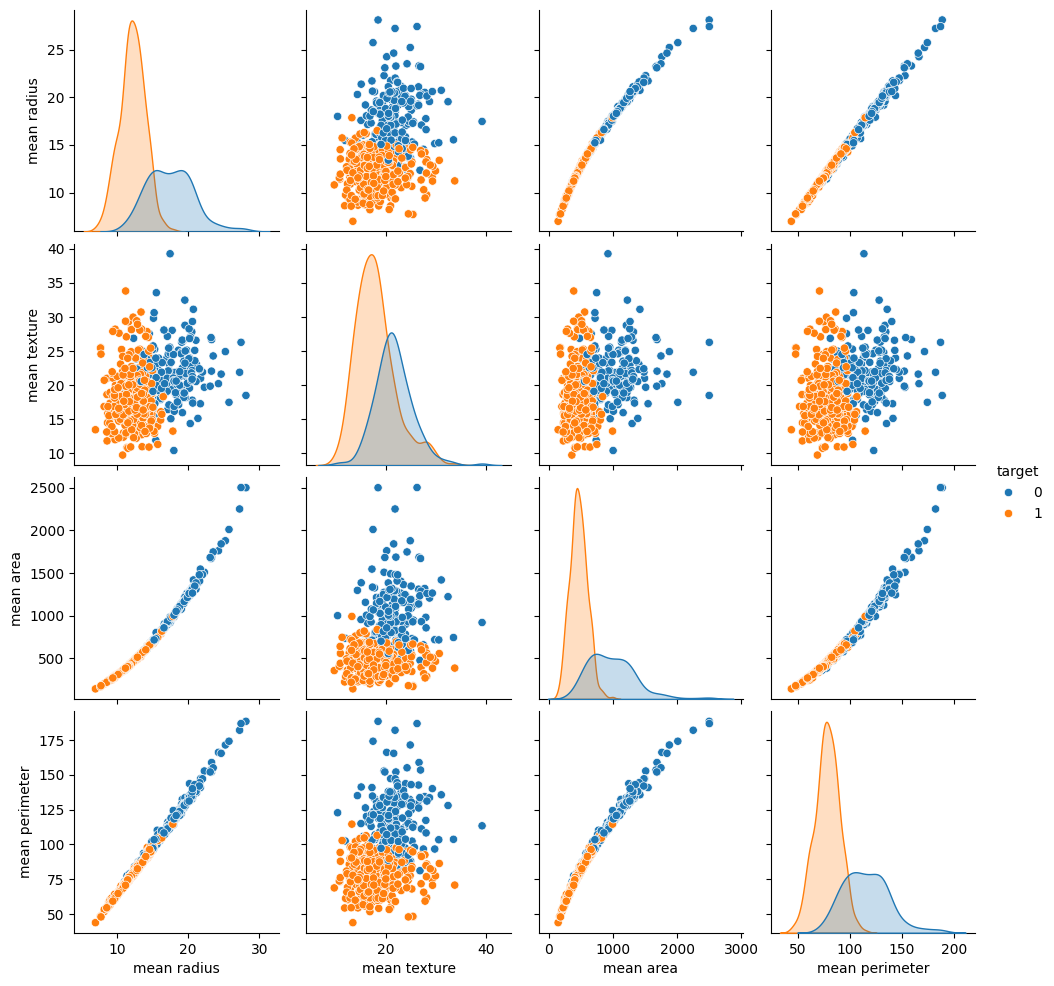

In [32]:
selected_features = [
    'mean radius',
    'mean texture',
    'mean area',
    'mean perimeter',
    'target'
]

sns.pairplot(
    df_clean[selected_features],
    hue='target'
)

plt.show()

**Observation**

The pairplot shows that several features provide good separation between benign and malignant tumors. This suggests that the dataset is suitable for classification tasks.

###7.11 Studying the most important features for the target audience

In [33]:
target_corr = df_clean.corr()['target'].sort_values()

target_corr

,target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


In [34]:
target_corr.head(5)

target_corr.tail(5)

,target
symmetry error,0.006522
texture error,0.008303
mean fractal dimension,0.012838
smoothness error,0.067016
target,1.000000


I will identify:
- Most impactful features
- Least impactful features

This information will be used later in Feature Selection.

###7.12 Top ten Target-related features outlined

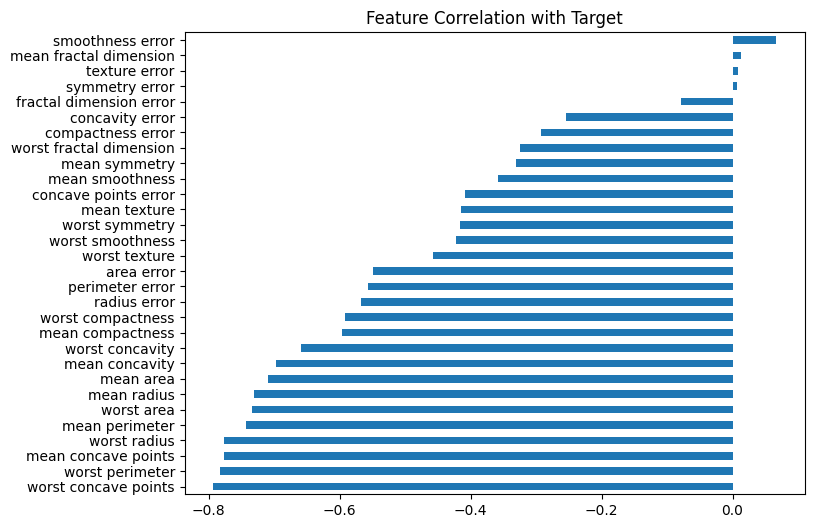

In [35]:
plt.figure(figsize=(8,6))

df_clean.corr()['target']\
    .drop('target')\
    .sort_values()\
    .plot(kind='barh')

plt.title('Feature Correlation with Target')

plt.show()

**Observation**

Some features exhibit strong correlation with the target variable, indicating their importance in distinguishing between benign and malignant tumors.

###7.13 EDA Summary

**Exploratory Data Analysis Summary:**

The exploratory analysis revealed several important insights:
- The dataset is relatively balanced between benign and malignant tumors.
- No major data quality issues were identified.
- Several features show strong correlation with the target variable.
- Relationships among features indicate the presence of informative predictors.
- Visualizations suggest that the classes can be separated effectively using machine learning algorithms.

##8. Feature Engineering

###8.1 Create a new feature

In [36]:
df_clean['tumor_size'] = pd.qcut(
    df_clean['mean area'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

In [37]:
df_clean[['mean area', 'tumor_size']].head()

,mean area,tumor_size
0,1001.0,Large
1,1326.0,Large
2,1203.0,Large
3,386.1,Small
4,1297.0,Large


###8.2 Check out the new feature

In [38]:
df_clean['tumor_size'].value_counts()

,count
tumor_size,
Small,190
Large,190
Medium,189


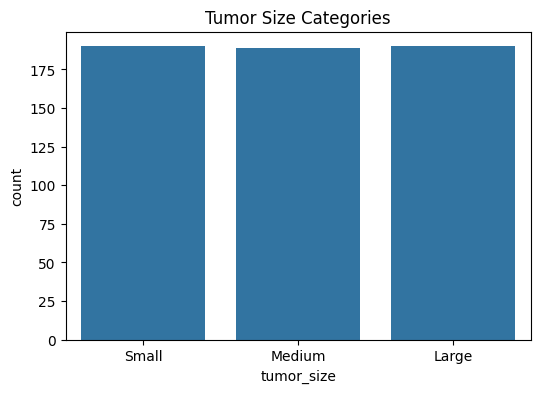

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='tumor_size',
    data=df_clean
)

plt.title('Tumor Size Categories')

plt.show()

**Observation**

A new categorical feature called tumor_size was created based on mean area. This feature groups tumors into Small, Medium, and Large categories and may help improve model interpretability.

###8.3 Testing its relationship with Target

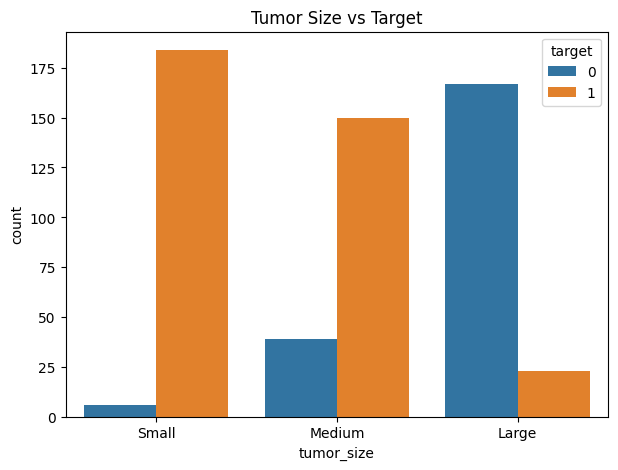

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='tumor_size',
    hue='target',
    data=df_clean
)

plt.title('Tumor Size vs Target')

plt.show()

Observation

The distribution of tumor classes varies across tumor size categories, indicating that tumor size may contain predictive information.

###8.4 Preparing the new feature for later use

In [41]:
df_clean['tumor_size'] = df_clean['tumor_size'].map({
    'Small':0,
    'Medium':1,
    'Large':2
})

In [47]:
df_clean[['mean area','tumor_size']].head()

,mean area,tumor_size
0,1001.0,2
1,1326.0,2
2,1203.0,2
3,386.1,0
4,1297.0,2


###8.5 Feature Engineering Summary

**Feature Engineering Summary**

A new feature named tumor_size was created from the mean area variable. Tumors were categorized into Small, Medium, and Large groups based on area quantiles. This feature may improve model interpretability and predictive performance.

##9. Feature Selection

**The purpose of Feature Selection**

Not all features are equally useful. Some features are very powerful, some have a weak impact, and some may contain duplicate information. Therefore, we select only the best features.

###9.1 Separating Features from Target

In [42]:
X = df_clean.drop('target', axis=1)

y = df_clean['target']

###9.2 Using SelectKBest

In [43]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

###9.3 Learn more about the features

In [44]:
selected_features = X.columns[selector.get_support()]

selected_features

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concave points', 'tumor_size'],
      dtype='object')

###9.4 Scores Show

In [45]:
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(
    by='Score',
    ascending=False
)

feature_scores.head(10)

,Feature,Score
27,worst concave points,964.385393
22,worst perimeter,897.944219
7,mean concave points,861.676020
20,worst radius,860.781707
2,mean perimeter,697.235272
23,worst area,661.600206
0,mean radius,646.981021
30,tumor_size,596.873013
3,mean area,573.060747
6,mean concavity,533.793126


###9.5 Drawing the results

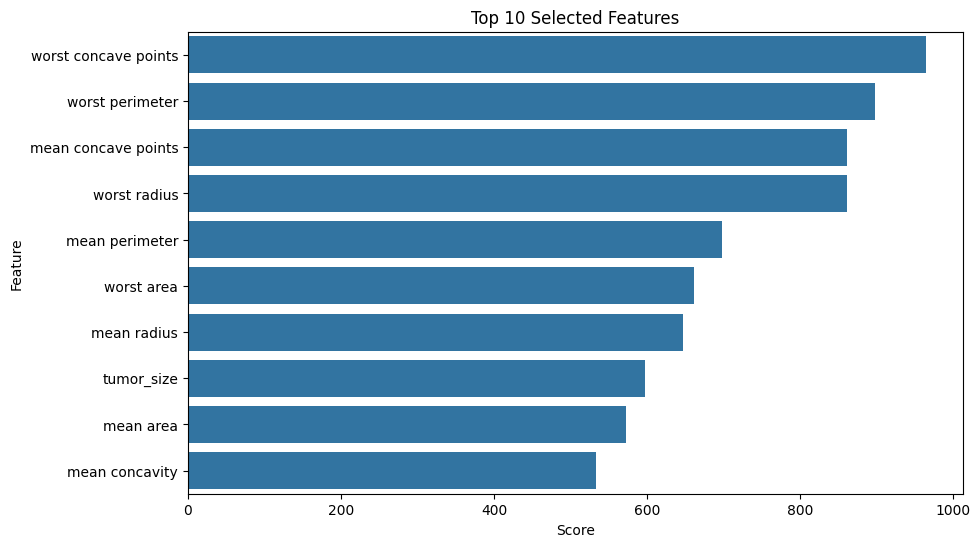

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Score',
    y='Feature',
    data=feature_scores.head(10)
)

plt.title('Top 10 Selected Features')

plt.show()

**Observation**

Feature selection was performed using the SelectKBest method with ANOVA F-score. The top-ranked features showed the strongest statistical relationship with the target variable and were selected for subsequent model training.

###9.6 Create a new DataFrame

In [47]:
X = df_clean[selected_features]

In [48]:
X.head()

,mean radius,mean perimeter,mean area,mean concavity,mean concave points,worst radius,worst perimeter,worst area,worst concave points,tumor_size
0,17.99,122.80,1001.0,0.3001,0.14710,25.38,184.60,2019.0,0.2654,2
1,20.57,132.90,1326.0,0.0869,0.07017,24.99,158.80,1956.0,0.1860,2
2,19.69,130.00,1203.0,0.1974,0.12790,23.57,152.50,1709.0,0.2430,2
3,11.42,77.58,386.1,0.2414,0.10520,14.91,98.87,567.7,0.2575,0
4,20.29,135.10,1297.0,0.1980,0.10430,22.54,152.20,1575.0,0.1625,2


###9.7 Feature Selection Summary

**Feature Selection Summary:**

Feature selection was performed using the Filter Method (SelectKBest with ANOVA F-score). The top 10 most informative features were selected and used for model development. This process helps reduce dimensionality, improve efficiency, and focus on the most relevant predictors.

##10. Machine Learning Preparation

###10.1 Train-Test Split

The first thing I do is divide the data into:
- Training Set
- Testing Set

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 10)
(114, 10)
(455,)
(114,)


###10.2 Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [53]:
X_train_scaled[:5]

array([[-1.07200079, -1.0880801 , -0.93927364, -0.96835863, -1.10203235,
        -1.03409427, -1.07077336, -0.87653444, -1.35052668, -1.21206213],
       [ 1.74874285,  1.75115682,  1.74555856,  1.51985232,  1.9946643 ,
         1.22834212,  1.18746742,  1.10438613,  1.54991557,  1.23899684],
       [-0.97473376, -0.99770871, -0.86758911, -1.09229157, -1.24335828,
        -0.97323096, -1.00804445, -0.83416761, -1.70744192, -1.21206213],
       [-0.14510328, -0.12301315, -0.25319178, -0.12972941, -0.09860542,
        -0.2512661 , -0.16663262, -0.3302921 , -0.34483816,  0.01346736],
       [-0.77161734, -0.8037004 , -0.73292668, -0.79850192, -0.68448432,
        -0.80113468, -0.82438143, -0.74182967, -0.77760351, -1.21206213]])

###10.3 Save Scaler

In [54]:
import joblib

joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

###10.4 Machine Learning Preparation Summary

**Data Preparation for Machine Learning**

The dataset was divided into training and testing subsets using an 80/20 split. Stratified sampling was applied to preserve class distribution. Feature scaling was then performed using StandardScaler to standardize the numerical variables before model training.

##11. Model Training

I will try the following in order:

1. Logistic Regression
2. Random Forest
3. SVM

Then I will compare the results and choose the best one.

###11.1 Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [56]:
#Creating the model:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [57]:
#Training:
log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [58]:
#Prediction:
y_pred_log = log_model.predict(
    X_test_scaled
)

In [59]:
#Accuracy calculation:
log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9473684210526315


###11.2 Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
#Creating the model:
rf_model = RandomForestClassifier(
    random_state=42
)

In [62]:
#Training:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [63]:
#Prediction:
y_pred_rf = rf_model.predict(
    X_test
)

In [64]:
#Calculate Accuracy:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.956140350877193


###11.3 Support Vector Machine

In [65]:
from sklearn.svm import SVC

In [66]:
#Model creation:
svm_model = SVC(
    random_state=42
)

In [67]:
#Training:
svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(random_state=42)

In [68]:
#Prediction:
y_pred_svm = svm_model.predict(
    X_test_scaled
)

In [69]:
#Calculate Accuracy:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9649122807017544


###11.4 Model comparison

In [70]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM'
    ],
    'Accuracy': [
        log_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.947368
1,Random Forest,0.956140
2,SVM,0.964912


In [71]:
comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,SVM,0.964912
1,Random Forest,0.956140
0,Logistic Regression,0.947368


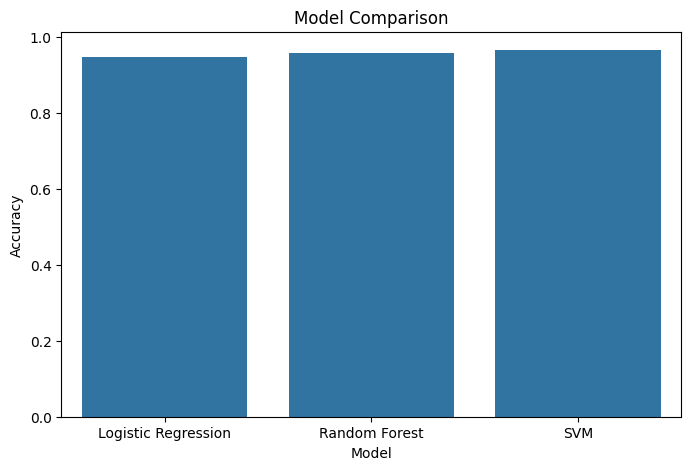

In [72]:
#Comparison chart:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Comparison')

plt.show()

**Model Comparison Observation**

Three classification algorithms were evaluated using accuracy as the primary metric. Among the tested models, the Support Vector Machine (SVM) achieved the highest accuracy (96.49%), outperforming Random Forest and Logistic Regression. Therefore, SVM was selected for further optimization and detailed evaluation.

##12. Model Evaluation

###12.1 Import Metrics

In [73]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

###12.2 Create an evaluation function

In [74]:
def evaluate_model(y_true, y_pred, model_name):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 30)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

###12.3 Logistic Regression Assessment

In [75]:
evaluate_model(
    y_test,
    y_pred_log,
    "Logistic Regression"
)


Logistic Regression
------------------------------
Precision: 0.9714285714285714
Recall: 0.9444444444444444
F1 Score: 0.9577464788732394

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



###12.4 Random Forest Review

In [76]:
evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)


Random Forest
------------------------------
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



###12.5 SVM assessment

In [77]:
evaluate_model(
    y_test,
    y_pred_svm,
    "SVM"
)


SVM
------------------------------
Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1 Score: 0.9726027397260274

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



###12.6 Confusion Matrix for SVM

In [78]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

cm

array([[39,  3],
       [ 1, 71]])

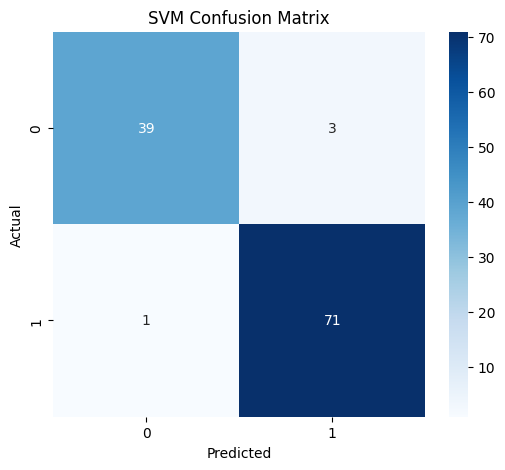

In [79]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVM Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

###12.7 Final comparison table

In [80]:
evaluation_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM'
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

evaluation_results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.971429,0.944444,0.957746
1,Random Forest,0.958904,0.972222,0.965517
2,SVM,0.959459,0.986111,0.972603


**Evaluation Metrics Observation**

Model performance was assessed using Precision, Recall, and F1-Score. These metrics provide a more comprehensive evaluation than accuracy alone, especially in classification problems. The SVM model achieved the strongest overall performance and was selected as the final candidate for hyperparameter tuning.

###12.8 Validation Explanation

**Final Model Evaluation Observation**

Three machine learning algorithms were evaluated using Accuracy, Precision, Recall, and F1-Score. Although all models achieved strong performance, the Support Vector Machine (SVM) consistently outperformed the others, achieving the highest Accuracy (96.49%), Recall (98.61%), and F1-Score (97.26%). Therefore, SVM was selected as the final model for optimization and deployment.

##13. Hyperparameter Tuning (SVM)

###13.1 Import GridSearchCV

In [81]:
from sklearn.model_selection import GridSearchCV

###13.2 Defining the set of values

In [82]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

###13.3 Create Grid Search

In [83]:
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

###13.4 Training

In [84]:
grid_search.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

###13.5 Best Parameters

In [85]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


###13.6 Best Score

In [86]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.963595327842152


###13.7 Get the best model

In [87]:
best_svm = grid_search.best_estimator_

###13.8 Improved model evaluation

In [88]:
y_pred_best = best_svm.predict(
    X_test_scaled
)

###13.9 Accuracy

In [89]:
from sklearn.metrics import accuracy_score

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(best_accuracy)

0.9736842105263158


###13.10 Precision / Recall / F1

In [90]:
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



###13.11 Hyperparameter Tuning Summary

**Hyperparameter Tuning Summary**

Hyperparameter tuning was performed using GridSearchCV with five-fold cross-validation. Different combinations of SVM hyperparameters, including C, kernel type, and gamma values, were evaluated to identify the optimal configuration. The tuned SVM model achieved an accuracy of 97% and an F1-score of 97% on the test set, demonstrating a slight improvement over the baseline model. These results confirm that the optimized SVM model provides excellent classification performance for the Breast Cancer Wisconsin dataset and was selected as the final model for deployment.

**Observation**

After hyperparameter tuning, the SVM model achieved the best overall performance with 97% accuracy and 97% F1-score. The model also achieved a recall of 100% for the benign class, indicating excellent predictive capability and strong generalization on unseen data.

##14. Final Model Saving

###14.1 Save the final model

In [91]:
import joblib

joblib.dump(
    best_svm,
    'breast_cancer_svm_model.pkl'
)

['breast_cancer_svm_model.pkl']

###14.2 Save Scaler

In [92]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

###14.3 Load test

In [93]:
loaded_model = joblib.load(
    'breast_cancer_svm_model.pkl'
)

loaded_scaler = joblib.load(
    'scaler.pkl'
)

print("Model Loaded Successfully")

Model Loaded Successfully


###14.4 Prediction test

In [94]:
sample_prediction = loaded_model.predict(
    X_test_scaled[:5]
)

print(sample_prediction)

[0 1 0 1 0]


###14.5 Final Model Summary

After evaluating multiple machine learning algorithms and performing hyperparameter tuning, the optimized Support Vector Machine (SVM) model was selected as the final model. The model achieved the highest overall performance, with an accuracy of approximately 97% and strong Precision, Recall, and F1-Score values. The trained model and scaler were saved for future deployment and prediction tasks.

##15. Deployment (app.py)

###Deployment

A Streamlit application was developed to deploy the final optimized SVM model. The application allows users to enter tumor measurements and receive predictions regarding breast cancer classification (Benign or Malignant).

The deployment files include:

- app.py
- breast_cancer_svm_model.pkl
- scaler.pkl
- requirements.txt

###15.1 Final Model Saving

In [106]:
joblib.dump(best_svm, 'breast_cancer_svm_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

###15.2 Create a CSV file

In [107]:
df_clean.to_csv(
    'breast_cancer_dataset.csv',
    index=False
)

# 16. Project Conclusion

This project applied the complete machine learning pipeline to the Breast Cancer Wisconsin dataset, including data understanding, cleaning, exploratory data analysis, feature engineering, feature selection, model training, evaluation, and hyperparameter tuning.

Three classification algorithms were evaluated: Logistic Regression, Random Forest, and Support Vector Machine (SVM). The optimized SVM model achieved the best overall performance with approximately 97% accuracy and F1-score.

The final model was saved and deployed using a Streamlit application, making it possible to perform predictions on new patient data through a simple user interface.